# Trouver le meilleur Pipeline pour colorisation d'images

### Objectives :
l'objectif primaire est de construire, train et validé un **modèle autoencodeur convolutionnel** capable de faire un mapping de couleur. En compressant les images dans un espace latent de dimension réduite puis en les reconstruisant vers des configurations cibles, le système apprend les similarités structurelles, les fréquences spatiales ainsi que les propriétés contextuelles des couleurs.

### Métrique utilisée pour l'évaluation des performances:
* **PSNR (Peak Signal-to-Noise Ratio):** mesure la fidélité au niveau des pixels ainsi que la précision de reconstruction des images générées par rapport aux images originales.
* **SSIM (Structural Similarity Index):** évalue les variations de structure, de luminance et de contraste afin de se rapprocher de la perception visuelle humaine.

## Environnement

In [8]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [3]:
!ls "/content/gdrive"

MyDrive


In [4]:
import sys
!mkdir -p "/content/gdrive/MyDrive/Colab Notebooks/ML_FDS"
my_local_drive='/content/gdrive/MyDrive/Colab Notebooks/ML_FDS'
sys.path.append(my_local_drive)

In [6]:
cd $my_local_drive

/content/gdrive/MyDrive/Colab Notebooks/ML_FDS


## Dependencies

In [9]:
import warnings  # Permet de gérer les avertissements
warnings.filterwarnings("ignore", category=FutureWarning)

# Librairies générales
import pandas as pd  # Manipulation de données en format tabulaire
from scipy.stats import randint  # Pour les distributions aléatoires
import numpy as np  # Calcul numérique
from numpy import mean, std  # Statistiques de base
import os  # Interaction avec le système d'exploitation
from os import listdir  # Liste les fichiers dans un répertoire
from os.path import isfile, join  # Fonctions pour gérer les chemins de fichiers
import sys  # Manipulation du système
import random  # Génération de nombres aléatoires
import cv2  # Librairie pour la vision par ordinateur
import zipfile  # Manipulation des archives ZIP
import struct
import tarfile
import urllib.request
from os.path import join
from pathlib import Path

# Librairie d'affichage
import matplotlib.pyplot as plt  # Visualisation de données
from PIL import Image, ImageDraw, ImageFilter, ImageEnhance  # Manipulation d'images avec Pillow

# Scikit-learn pour l'apprentissage automatique
from sklearn.decomposition import PCA  # Analyse en composantes principales(ACP)

# TensorFlow et Keras pour le deep learning
import tensorflow as tf  # Framework principal pour l'apprentissage profond
import keras  # API de haut niveau pour TensorFlow
from keras import layers  # Modules de construction de modèles Keras
from keras import models  # Définition et manipulation des modèles
from keras import optimizers  # Optimisateurs pour les modèles Keras
from keras.optimizers import Adam  # Optimiseur Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator  #Générateur

# Utilitaires Keras pour le traitement d'images
from keras.utils import img_to_array, load_img  # Conversion images en tableaux
from keras.callbacks import (ModelCheckpoint,
                             EarlyStopping, ReduceLROnPlateau)  # Gestion des checkpoints
from keras import backend as K  # Backend Keras pour opérations de bas niveau
from keras.models import Model, load_model  # Définition/chargement des modèles
from keras.layers import LeakyReLU  # Activation LeakyReLU
from keras.preprocessing import image  # Prétraitement des images

# Couches Keras pour les modèles convolutifs et autres
from keras.layers import (Input, Conv2D, Flatten, Dense, Conv2DTranspose,
                          Reshape, Activation,
                          BatchNormalization,
                          Dropout, Concatenate )  # Couches pour CNN et autoencoders
from keras.layers import (InputLayer, MaxPooling2D,
                          UpSampling2D)

## Récupération de données 
Nous avons récupérer le dataset Humans fournit dans les ressources de l'enseignant, qui comprend ~7000 images
Nous avons également utilisé STL-10, qui contient un grand nombre d’images naturelles non annotées, afin de diversifier
et d’enrichir les données d’entraînement.
Les images ont été extraites depuis le format binaire original,converties en RGB, puis redimensionnées à une résolution de 128×128 pixels
pour être compatibles avec notre pipeline de traitement.

In [10]:
import shutil
# Nom local de l'archive et URL source
zip_file = "Humans.zip"
zip_url = "https://www.lirmm.fr/~poncelet/Ressources/Humans.zip"

# Répertoire cible après extraction
src_dir = "Humans"
image_dir = os.path.join(src_dir, "train")

# Vérifie si le dossier de destination contient des images
def humans_already_present():
    return os.path.exists(image_dir) and any(f.endswith(".png") for f in os.listdir(image_dir))

# Téléchargement et extraction seulement si besoin
if not humans_already_present():
    print("Aucune image trouvée dans Humans/train. Téléchargement et extraction en cours...")

    # Télécharger si l'archive n'est pas déjà présente
    if not os.path.exists(zip_file):
        print(f"Téléchargement de {zip_file}...")
        !wget -O {zip_file} {zip_url}
    else:
        print(f"{zip_file} déjà présent, téléchargement ignoré.")

    # Extraction dans le répertoire courant
    with zipfile.ZipFile(zip_file, "r") as zip_ref:
      for member in zip_ref.namelist():
        if not member.startswith("__MACOSX"):
            zip_ref.extract(member, ".")


    print("Archive extraite dans le répertoire courant.")

    # Suppression de l'archive après extraction
    os.remove(zip_file)
else:
    print("Le dossier Humans/train existe déjà et contient des images. Téléchargement ignoré.")

Le dossier Humans/train existe déjà et contient des images. Téléchargement ignoré.


In [11]:
HUMANS_DIR = "Humans/train"
STL10_DIR  = 'STL10/train'         # sera créé
COMBINED_DIRS = [HUMANS_DIR, STL10_DIR]   # les deux ensemble

TARGET_SIZE = (128, 128)
BATCH_SIZE  = 32

os.makedirs(STL10_DIR, exist_ok=True)

Humans/train : 6834 images


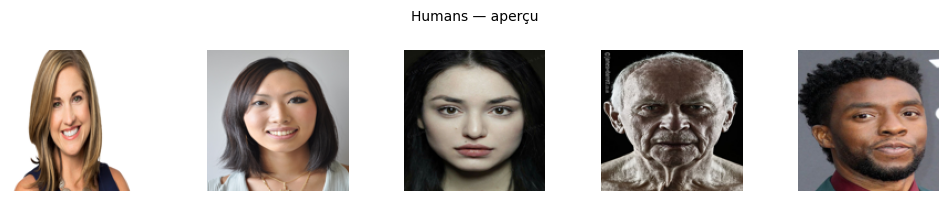

In [12]:
humans_files = [f for f in os.listdir(HUMANS_DIR) if f.endswith('.png')]
print(f'Humans/train : {len(humans_files)} images')

# Aperçu rapide
sample = random.sample(humans_files, 5)
fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for ax, fname in zip(axes, sample):
    ax.imshow(Image.open(join(HUMANS_DIR, fname)))
    ax.axis('off')
plt.suptitle('Humans — aperçu', fontsize=10)
plt.tight_layout()
plt.show()

In [13]:
STL10_URL     = 'http://ai.stanford.edu/~acoates/stl10/stl10_binary.tar.gz'
STL10_ARCHIVE = 'stl10_binary.tar.gz'
STL10_N       = 12_000   # combien d'images on extrait du split unlabeled (max 100 000)


def download_stl10():
    if os.path.exists(STL10_ARCHIVE):
        print("archive déjà présente")
        return

    print("téléchargement STL-10")

    urllib.request.urlretrieve(STL10_URL, STL10_ARCHIVE)

    if os.path.getsize(STL10_ARCHIVE) < 1e8:
        raise ValueError("Téléchargement incomplet : fichier cassé")

    print("OK téléchargement terminé")


def extract_stl10_unlabeled(n=STL10_N):
    """
    Extrait n images du split 'unlabeled' de STL-10 vers STL10_DIR.

    Format binaire STL-10 :
    - Chaque image = 27 648 octets (3 canaux × 96 × 96)
    - Stockage channel-first : tous les R, puis tous les G, puis tous les B
    - Pas d'en-tête, juste une séquence d'images bout à bout

    On redimensionne à 128×128 en Lanczos (meilleure qualité que BILINEAR
    pour un upscaling de 96→128).
    """
    existing = [f for f in os.listdir(STL10_DIR) if f.endswith('.png')]
    if len(existing) >= n:
        print(f'STL10/train contient déjà {len(existing)} images, extraction ignorée.')
        return

    print(f'Extraction de {n} images depuis l\'archive...')

    with tarfile.open(STL10_ARCHIVE, 'r:gz') as tar:
        # Le fichier unlabeled est à ce chemin dans l'archive
        member = tar.getmember('stl10_binary/unlabeled_X.bin')
        f      = tar.extractfile(member)

        IMAGE_BYTES = 3 * 96 * 96   # 27 648 octets par image
        saved = 0

        while saved < n:
            raw = f.read(IMAGE_BYTES)
            if len(raw) < IMAGE_BYTES:
                break   # fin du fichier (ne devrait pas arriver avant 100 000)

            # Reshape channel-first → channel-last
            # (3, 96, 96) → transpose → (96, 96, 3)
            arr = np.frombuffer(raw, dtype=np.uint8)
            arr = arr.reshape(3, 96, 96).transpose(1, 2, 0)   # channel-last

            img = Image.fromarray(arr, mode='RGB')
            img = img.resize(TARGET_SIZE, Image.LANCZOS)   # 96→128

            img.save(join(STL10_DIR, f'stl10_{saved:06d}.png'))
            saved += 1

            if saved % 1000 == 0:
                print(f'  {saved}/{n} images extraites')

    print(f'Extraction terminée : {saved} images dans {STL10_DIR}')


# ── Exécution ─────────────────────────────────────────────────────────────────
download_stl10()
extract_stl10_unlabeled(n=STL10_N)

archive déjà présente
STL10/train contient déjà 12000 images, extraction ignorée.


STL10/train : 12000 images


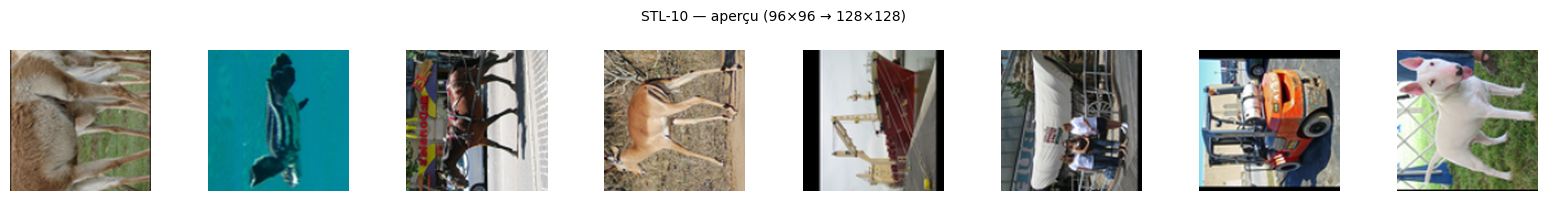


Total combiné : 6834 (Humans) + 12000 (STL-10) = 18834 images


In [14]:
# Vérification et aperçu
stl_files = [f for f in os.listdir(STL10_DIR) if f.endswith('.png')]
print(f'STL10/train : {len(stl_files)} images')

sample = random.sample(stl_files, 8)
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for ax, fname in zip(axes, sample):
    ax.imshow(Image.open(join(STL10_DIR, fname)))
    ax.axis('off')
plt.suptitle('STL-10 — aperçu (96×96 → 128×128)', fontsize=10)
plt.tight_layout()
plt.show()

# Bilan
total = len(humans_files) + len(stl_files)
print(f'\nTotal combiné : {len(humans_files)} (Humans) + {len(stl_files)} (STL-10) = {total} images')

## fonctions de corruption d'image récupérer depuis un notre notebook

on s'intéresse surtout sur rgbToGreyScale qui transforme une image rgb au greyscale / noir et blanc

In [15]:
def addMask(image: Image.Image) -> np.array :
    """ Ajoute un masque noir de taille aléatoire à une position aléatoire"""
    size = random.randint(30,60)
    start = random.randint(0,128-size)
    out = image.copy()
    ImageDraw.Draw(out).rectangle(
        [(start, start), (start + size, start + size)], fill='black'
    )
    return np.array(out)

def addNoise(image: Image.Image, level: float = 4.0) -> Image.Image:
    """Ajoute du bruit gaussien, l'intensité est varié d'une image à l'autre"""
    scale = 25 * level * random.uniform(0.8, 1.2)
    arr = np.array(image, dtype=np.float32)
    noisy = arr + np.random.normal(0, scale, arr.shape)
    noisy = np.clip(noisy, 0, 255).astype(np.uint8)
    return Image.fromarray(noisy)

def rgbToGreyScale(image: Image.Image) -> np.ndarray:
    """Convertit l'image rgb au niveau de gris"""
    gray = image.convert("L").resize((128, 128))
    arr = np.array(gray)
    return np.stack([arr] * 3, axis=-1)

def addBlur(image: Image.Image, radius: float = None) -> np.ndarray:
    """Applique un flou gaussien """
    if radius is None:
        radius = random.uniform(2.0, 5.0)
    blurred = image.filter(ImageFilter.GaussianBlur(radius=radius))
    return np.array(blurred)

def combined_filters(image: Image.Image) -> np.ndarray:
    """Applique aléatoirement une combinaison de corruptions """
    img = image.copy()
    if random.random() < 0.5:
        img = addNoise(img, level=2.0)
    if random.random() < 0.5:
        img = Image.fromarray(addMask(img))
    if random.random() < 0.3:
        img = Image.fromarray(addBlur(img))
    return np.array(img)


#autres filtres à tester si ça marche avec les autres fonctions :

def add_scratch(image: Image.Image) -> np.ndarray:
    """Ajoute des rayures aléatoires (comme sur une vieille pellicule)"""
    img = np.array(image)
    num_scratch = random.randint(1, 5)
    for _ in range(num_scratch):
        y_start = random.randint(0, img.shape[0])
        x_start = random.randint(0, img.shape[1])
        length = random.randint(20, 100)
        thickness = random.randint(1, 3)
        angle = random.uniform(0, 2 * np.pi)
        x_end = int(x_start + length * np.cos(angle))
        y_end = int(y_start + length * np.sin(angle))
        cv2.line(img, (x_start, y_start), (x_end, y_end),
                 (255, 255, 255) if random.random() > 0.5 else (0, 0, 0), thickness)
    return img

def add_dust_and_scratches(image: Image.Image) -> np.ndarray:
    """Ajoute de la poussière (petits points blancs/noirs)"""
    img = np.array(image)
    mask = np.random.random(img.shape[:2]) < 0.005  # 0.5% de pixels
    dust_color = np.random.choice([0, 255], size=mask.sum())
    img[mask] = dust_color[:, np.newaxis]
    return img

def add_jpeg_artifacts(image: Image.Image, quality: int = None) -> np.ndarray:
    """Simule une compression JPEG agressive"""
    if quality is None:
        quality = random.randint(10, 60)
    _, encoded = cv2.imencode('.jpg', cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR),
                               [cv2.IMWRITE_JPEG_QUALITY, quality])
    decoded = cv2.imdecode(encoded, cv2.IMREAD_COLOR)
    return cv2.cvtColor(decoded, cv2.COLOR_BGR2RGB)

def add_pixelation(image: Image.Image, block_size: int = None) -> np.ndarray:
    """Effet pixelisé (comme une basse résolution)"""
    if block_size is None:
        block_size = random.randint(4, 16)
    h, w = image.size
    small = image.resize((w // block_size, h // block_size), Image.NEAREST)
    return np.array(small.resize((w, h), Image.NEAREST))

def add_glitch_effect(image: Image.Image) -> np.ndarray:
    """Effet 'glitch' numérique (décalage de bandes)"""
    img = np.array(image)
    h, w = img.shape[:2]
    num_glitches = random.randint(3, 10)

    for _ in range(num_glitches):
        y_start = random.randint(0, h - 20)
        y_end = y_start + random.randint(5, 30)
        shift = random.randint(-30, 30)

        # Décale une bande horizontale
        glitch_band = img[y_start:y_end, :].copy()
        if shift > 0:
            glitch_band = np.roll(glitch_band, shift, axis=1)
            if shift > 0:
                glitch_band[:, :shift] = 0
        else:
            glitch_band = np.roll(glitch_band, shift, axis=1)
            if shift < 0:
                glitch_band[:, shift:] = 0
        img[y_start:y_end, :] = glitch_band

    return img

#dictionnaire
corruption_funcs = {
    'mask' : lambda img: addMask(img),
    'noise' : lambda img: np.array(addNoise(img)),
    'blur' : lambda img: addBlur(img),
    'blackwhite' : lambda img: rgbToGreyScale(img),
    'combined' : lambda img: combined_filters(img),
}

## Data augmentation

Les augmentations appliquées sont les suivantes :

- **Symétrie horizontale aléatoire** : permet de créer des variations d’orientation des images.
- **Recadrage aléatoire suivi d’un redimensionnement** : simule des variations de zoom et de cadrage.
- **Modification de la saturation** : introduit des variations de couleurs afin de rendre le modèle moins sensible aux différences chromatiques.
- **Variation de la luminosité** : améliore la robustesse face aux changements d’éclairage.

Deux implémentations ont été utilisées :

- une version basée sur la bibliothèque PIL (récupérer d'un autre notebook)
- une version optimisée avec TensorFlow pour l’entraînement du modèle (compatible avec l'utilisation GPU).

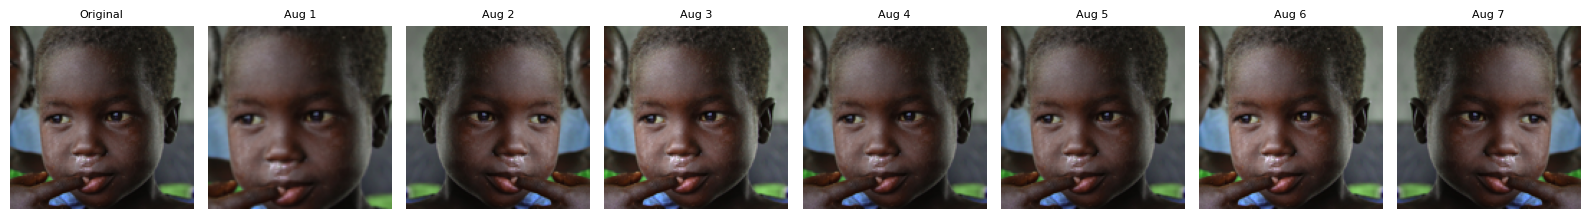

In [16]:
def augment(img: Image.Image) -> Image.Image:
    """
    Augmentation légère appliquée sur l'image originale.
    Paramètre : PIL Image RGB 128×128
    Retour    : PIL Image RGB 128×128 augmentée
    """

    # flip horizontal
    if random.random() < 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    # random crop + resize
    if random.random() < 0.3:
        margin = random.randint(6, 18)
        img = img.crop((margin, margin, 128 - margin, 128 - margin))
        img = img.resize(TARGET_SIZE, Image.BILINEAR)

    # saturation
    if random.random() < 0.4:
        factor = random.uniform(0.6, 1.4)
        img = ImageEnhance.Color(img).enhance(factor)

    # luminosité
    if random.random() < 0.3:
        factor = random.uniform(0.75, 1.25)
        img = ImageEnhance.Brightness(img).enhance(factor)

    return img


# démo
test_path = join(HUMANS_DIR, random.choice(humans_files))
test_img  = Image.open(test_path).convert('RGB')

fig, axes = plt.subplots(1, 8, figsize=(16, 2.5))
axes[0].imshow(test_img);  axes[0].set_title('Original', fontsize=8);  axes[0].axis('off')
for i in range(1, 8):
    axes[i].imshow(augment(test_img))
    axes[i].set_title(f'Aug {i}', fontsize=8)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### version compatible avec GPU

In [17]:
def tf_augment(img):
    """img : float32 tensor [H, W, 3] in [0,1]"""
    img = tf.image.random_flip_left_right(img)
    if tf.random.uniform(()) < 0.3:
        margin = tf.random.uniform((), 6, 18, dtype=tf.int32)
        crop_size = 128 - margin
        img = tf.image.random_crop(img, [crop_size, crop_size, 3])
        img = tf.image.resize(img, [128, 128])
    img = tf.image.random_saturation(img, 0.6, 1.4)
    img = tf.image.random_brightness(img, 0.25)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img

In [18]:
def tf_corrupt(img, typeimage):
    """img : float32 [H,W,3] in [0,1]"""
    if typeimage == 'blackwhite':
        gray = tf.image.rgb_to_grayscale(img)
        return tf.repeat(gray, 3, axis=-1)

    elif typeimage == 'noise':
        scale = tf.random.uniform((), 0.05, 0.15)
        noise = tf.random.normal(tf.shape(img), stddev=scale)
        return tf.clip_by_value(img + noise, 0.0, 1.0)

    elif typeimage == 'blur':
        k = tf.random.uniform((), 2, 5, dtype=tf.int32)
        x = img[tf.newaxis]
        x = tf.nn.avg_pool2d(x, ksize=k, strides=1, padding='SAME')
        return x[0]

    elif typeimage == 'mask':
        size  = tf.random.uniform((), 30, 60, dtype=tf.int32)
        start = tf.random.uniform((), 0, 128 - size,  dtype=tf.int32)
        mask = tf.ones([128, 128, 3], dtype=tf.float32)
        zeros = tf.zeros([size, size, 3])
        indices = [[i, j, c]
                   for i in range(size) for j in range(size) for c in range(3)]
        pad_before = [start, start, 0]
        pad_after  = [128 - start - size, 128 - start - size, 0]
        hole = 1.0 - tf.pad(tf.ones([size, size, 3]),
                             [[start, 128-start-size],
                              [start, 128-start-size], [0,0]])
        return img * hole

    elif typeimage == 'combined':
        if tf.random.uniform(()) < 0.5:
            img = tf_corrupt(img, 'noise')
        if tf.random.uniform(()) < 0.5:
            img = tf_corrupt(img, 'mask')
        if tf.random.uniform(()) < 0.3:
            img = tf_corrupt(img, 'blur')
        return img
    return img

In [19]:
# def make_generator(
#     folders: list,
#     target_size: tuple,
#     batch_size: int,
#     typeimage: str  = 'blackwhite',
#     shuffle: bool = True,
#     use_augment: bool = True
# ):
#     """
#     géénérateur infini de paires (corrompue, originale) depuis plusieurs dossiers.

#     Différences avec myImageGenerator :
#     - Accepte une liste de dossiers
#     - applique augment() avant la corruption (train) si use_augment = True
#     """
#     corrupt_fn = corruption_funcs[typeimage]
#     all_files = []
#     for folder in folders:
#         all_files += [
#             join(folder, f)
#             for f in os.listdir(folder)
#             if f.endswith('.png')
#         ]

#     print(f'[make_generator] {len(all_files)} images au total '
#           f'({typeimage}, augment={use_augment})')

#     if shuffle:
#         random.shuffle(all_files)

#     idx = 0
#     while True:
#         if idx + batch_size > len(all_files):
#             if shuffle:
#                 random.shuffle(all_files)
#             idx = 0

#         batch_paths = all_files[idx : idx + batch_size]
#         originals, corrupted = [], []

#         for path in batch_paths:
#             img = Image.open(path).convert('RGB').resize(target_size, Image.BILINEAR)

#             if use_augment:
#                 img = augment(img)

#             originals.append(np.array(img) / 255.0)
#             corrupted.append(corrupt_fn(img) / 255.0)

#         idx += batch_size
#         yield (
#             np.array(corrupted,  dtype=np.float32),
#             np.array(originals,  dtype=np.float32)
#         )

## Création du pipeline de données TensorFlow (compatible GPU)
Un pipeline de données a été mis en place pour optimiser le chargement et le prétraitement des images pendant l’entraînement.

La fonction `make_tf_dataset()` permet de :
- charger automatiquement toutes les images PNG provenant des différents datasets,
- redimensionner les images à une résolution uniforme
- normaliser les pixels dans l’intervalle \([0,1]\)
- appliquer les augmentations de données
- générer une version dégradée de l’image à l’aide de la fonction `tf_corrupt()`
- construire des batches prêts pour l’entraînement du modèle

Le pipeline retourne la paire : `(l’image corrompue, l’image originale)`

In [3]:
def make_tf_dataset(folders, target_size, batch_size,
                    typeimage='blackwhite', use_augment=True):

    all_files = []
    for folder in folders:
        all_files += [join(folder, f)
                      for f in os.listdir(folder) if f.endswith('.png')]
    print(f'[make_tf_dataset] {len(all_files)} images ({typeimage}, augment={use_augment})')

    def load_image(path):
        raw  = tf.io.read_file(path)
        img  = tf.image.decode_png(raw, channels=3)
        img  = tf.image.resize(img, target_size)
        img  = tf.cast(img, tf.float32) / 255.0
        return img

    def process(img):
        if use_augment:
            img = tf_augment(img)
        orig = img
        corr = tf_corrupt(img, typeimage)
        return corr, orig

    ds = tf.data.Dataset.from_tensor_slices(all_files)

    # Charger toutes les images cache en RAM (≈870 Mo en uint8)
    ds = ds.map(load_image, num_parallel_calls=2)
    #ds = ds.cache()# clé : lecture disque UNE SEULE FOIS
    ds = ds.repeat()

    if use_augment:
        ds = ds.shuffle(2000) #it used to be all files but that took too much ram space
    ds = ds.map(process, num_parallel_calls=2)
    ds = ds.batch(batch_size, drop_remainder=True)
    ds = ds.prefetch(2)
    return ds

In [22]:
# test_gen   = make_generator(COMBINED_DIRS, TARGET_SIZE, batch_size=8,
#                              typeimage='blackwhite', use_augment=True)
# x_corr, x_orig = next(test_gen)

# print(f'Shape corrupted : {x_corr.shape}')
# print(f'Shape original  : {x_orig.shape}')
# print(f'Range [min, max] : [{x_corr.min():.2f}, {x_corr.max():.2f}]')

# fig, axes = plt.subplots(2, 8, figsize=(16, 4))
# for i in range(8):
#     axes[0, i].imshow(x_orig[i])
#     axes[0, i].axis('off')
#     axes[1, i].imshow(x_corr[i], cmap='gray')
#     axes[1, i].axis('off')
# axes[0, 0].set_ylabel('Originale', fontsize=9)
# axes[1, 0].set_ylabel('N&B', fontsize=9)
# plt.suptitle('Batch test', fontsize=10)
# plt.tight_layout()
# plt.show()

In [23]:
n_humans = len([f for f in os.listdir(HUMANS_DIR) if f.endswith('.png')])
n_stl = len([f for f in os.listdir(STL10_DIR)  if f.endswith('.png')])
n_total = n_humans + n_stl

steps_train = max(1, int(n_total * 0.8) // BATCH_SIZE)
steps_val = max(1, int(n_total * 0.2) // BATCH_SIZE)

print('=' * 45)
print(f'  Humans/train  : {n_humans:>6} images')
print(f'  STL10/train   : {n_stl:>6} images')
print(f'  Total brut    : {n_total:>6} images')
print(f'  Avec augment  : ~{n_total * 3:>5} images effectives (×3 diversité)')
print('=' * 45)
print(f'  steps_per_epoch (train, 80 %) : {steps_train}')
print(f'  validation_steps  (val, 20 %) : {steps_val}')
print('=' * 45)
print()
print('Utilisation dans train_task() :')
print()
print('  train_gen = make_generator(COMBINED_DIRS, TARGET_SIZE,')
print('                              BATCH_SIZE, typeimage, use_augment=True)')
print('  val_gen   = make_generator(COMBINED_DIRS, TARGET_SIZE,')
print('                              BATCH_SIZE, typeimage, use_augment=False)')

  Humans/train  :   6834 images
  STL10/train   :  12000 images
  Total brut    :  18834 images
  Avec augment  : ~56502 images effectives (×3 diversité)
  steps_per_epoch (train, 80 %) : 470
  validation_steps  (val, 20 %) : 117

Utilisation dans train_task() :

  train_gen = make_generator(COMBINED_DIRS, TARGET_SIZE,
                              BATCH_SIZE, typeimage, use_augment=True)
  val_gen   = make_generator(COMBINED_DIRS, TARGET_SIZE,
                              BATCH_SIZE, typeimage, use_augment=False)


## Fonction de perte

selon l’article *Loss Functions for Image Restoration with Neural Networks* nous avons testé différentes fonctions de perte.

En plus des pertes classiques $L_1$, nous avons implémenté des pertes perceptuelles basées sur SSIM et MS-SSIM, ainsi qu’une combinaison des deux avec $L_1$.

L’objectif est de mieux aligner l’optimisation du réseau avec la perception visuelle humaine, plutôt que de se limiter à une erreur pixel-à-pixel.

In [24]:
def l1_loss(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))

def mix_loss(alpha=0.84):
    def loss(y_true, y_pred):
        ms = tf.image.ssim(y_true, y_pred, max_val=1.0)
        ms = tf.clip_by_value(ms, 0.0, 1.0)
        return alpha * (1.0 - tf.reduce_mean(ms)) + (1.0 - alpha) * l1_loss(y_true, y_pred)
    loss.__name__ = f'mix_loss_a{int(alpha*100)}'
    return loss

def make_warmup_loss(final_alpha=0.84):
    """
    Retourne (loss_fn, alpha_var) où alpha_var est une tf.Variable.
    """
    # démare avec l1
    alpha_var = tf.Variable(0.0, trainable=False, dtype=tf.float32, name='ssim_alpha')

    def loss_fn(y_true, y_pred):
        l1 = tf.reduce_mean(tf.abs(y_true - y_pred))

        #partie MS-SSIM: Calculée toujours, sa contribution est contrôlée par alpha_var
        ms_term_val = 1.0 - tf.reduce_mean(
            tf.clip_by_value(
                tf.image.ssim(y_true, y_pred, max_val=1.0),
                0.0, 1.0
            )
        )

        return alpha_var * ms_term_val + (1.0 - alpha_var) * l1

    loss_fn.__name__ = 'warmup_mix_loss'
    return loss_fn, alpha_var


class WarmupLossCallback(tf.keras.callbacks.Callback):
    """
    Modifie alpha_var à la fin de l'époque de warm-up.
    """
    def __init__(self, alpha_var, warmup_epochs, final_alpha=0.84):
        super().__init__()
        self.alpha_var     = alpha_var
        self.warmup_epochs = warmup_epochs
        self.final_alpha   = final_alpha
        self.switched      = False

    def on_epoch_end(self, epoch, logs=None):
        if epoch == self.warmup_epochs - 1 and not self.switched:
            self.alpha_var.assign(self.final_alpha)
            self.switched = True
            print(f'\n[WarmupLoss] époque {epoch+1} : '
                  f'alpha 0.0 to {self.final_alpha}  (MS-SSIM activé)')

## construction d'un autoencodeur U-Net

In [25]:
def build_unet_autoencoder(input_shape=(128, 128, 3)):
    def conv_block(x, filters, name):
        x = Conv2D(filters, 3, strides=2, padding='same', name=f'{name}_conv')(x)
        x = BatchNormalization(name=f'{name}_bn')(x)
        x = LeakyReLU(name=f'{name}_act')(x)
        return x
    def deconv_block(x, skip, filters, name):
        x = Conv2DTranspose(filters, 3, strides=2, padding='same', name=f'{name}_deconv')(x)
        x = BatchNormalization(name=f'{name}_bn1')(x)
        x = LeakyReLU(name=f'{name}_act1')(x)
        x = Concatenate(name=f'{name}_skip')([x, skip])
        x = Conv2D(filters, 3, padding='same', name=f'{name}_merge')(x)
        x = BatchNormalization(name=f'{name}_bn2')(x)
        x = LeakyReLU(name=f'{name}_act2')(x)
        return x
    inputs = Input(shape=input_shape, name='input')
    e1 = conv_block(inputs, 32,  'enc1')
    e2 = conv_block(e1,     64,  'enc2')
    e3 = conv_block(e2,     128, 'enc3')
    e4 = conv_block(e3,     256, 'enc4')
    bn = conv_block(e4,     256, 'bottleneck')
    d4 = deconv_block(bn, e4, 256, 'dec4')
    d3 = deconv_block(d4, e3, 128, 'dec3')
    d2 = deconv_block(d3, e2,  64, 'dec2')
    d1 = deconv_block(d2, e1,  32, 'dec1')
    outputs = Conv2DTranspose(3, 3, strides=2, padding='same',
                               activation='sigmoid', name='output')(d1)
    return Model(inputs, outputs, name='unet_autoencoder')

In [26]:
def get_fresh_model():
    """
    Crée un nouveau modèle U-Net avec des poids aléatoires.
    """
    tf.keras.backend.clear_session()
    model = build_unet_autoencoder()
    return model

In [27]:
model_dir = './aeplus_models/'
EPOCHS    = 50
PATIENCE  = 10
BATCH_SIZE = 64

La fonction `train_task()` définit le pipeline complet d’entraînement du modèle pour une tâche de restauration/colorisation d’images.

**Stratégie de loss (warm-up)**
- pendant les premières époques (*warm-up*), seule la perte L1 est utilisée,
- ensuite, la contribution de MS-SSIM est progressivement activée via une variable dynamique `alpha_var`,
- ce mécanisme permet d’éviter des instabilités initiales liées aux pertes perceptuelles.

In [85]:
def train_task(typeimage, model_name, epochs=EPOCHS, warmup=7, final_alpha=0.84):
    """
    Entraîne un U-Net propre sur une tâche de restauration

    Paramètres :
    - typeimage  : 'blackwhite', 'mask', 'noise', 'blur', 'combined'
    - model_name : nom du fichier .keras à sauvegarder
    - epochs     : nombre max d'époques
    - warmup     : nb d'époques avec L1 seul avant d'activer MS-SSIM
    - alpha      : poids de MS-SSIM dans mix_loss
    """
    print(f'\n{"═"*60}')
    print(f'  Tâche : {typeimage} saved in {model_name}, warmup : {warmup} ep.   alpha_final : {final_alpha}')
    print(f'{"═"*60}\n')

    model = get_fresh_model()
    # créer la loss et récupérer la var qu'on passera au callback
    loss_fn, alpha_var = make_warmup_loss(final_alpha=final_alpha)
    model.compile(optimizer=Adam(1e-3), loss=loss_fn)

    #n_images    = len([f for f in os.listdir(image_dir) if f.endswith('.png')])
    steps_train = max(1, int(n_total * 0.8) // BATCH_SIZE)
    steps_val   = max(1, int(n_total * 0.2) // BATCH_SIZE)

    train_gen = make_tf_dataset(COMBINED_DIRS, TARGET_SIZE, BATCH_SIZE, typeimage, use_augment=True)
    val_gen   = make_tf_dataset(COMBINED_DIRS, TARGET_SIZE, BATCH_SIZE, typeimage, use_augment=False)

    model_path = join(model_dir, model_name)

    callbacks = [
        WarmupLossCallback(alpha_var=alpha_var, warmup_epochs=warmup, final_alpha=final_alpha),
        EarlyStopping(
            monitor='val_loss', patience=PATIENCE,
            restore_best_weights=True, verbose=1),
        ModelCheckpoint(
            filepath=model_path, monitor='val_loss',
            save_best_only=True, verbose=0 ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=4, min_lr=1e-6, verbose=1),
    ]

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )

    plot_history(history, typeimage)
    return model, history


def plot_history(history, title=''):
    """Courbe d'apprentissage avec annotation du point de switch loss."""
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(history.history['loss'],     label='Entraînement', lw=2)
    ax.plot(history.history['val_loss'], label='Validation',   lw=2, linestyle='--')
    ax.set_xlabel('Époque')
    ax.set_ylabel('Perte')
    ax.set_title(f"Courbe d'apprentissage {title}")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


════════════════════════════════════════════════════════════
  Tâche : blackwhite saved in unet_bw_combined.keras, warmup : 10 ep.   alpha_final : 0.84
════════════════════════════════════════════════════════════

[make_tf_dataset] 18834 images (blackwhite, augment=True)
[make_tf_dataset] 18834 images (blackwhite, augment=False)
Epoch 1/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 228s 319ms/step - loss: 0.0665 - val_loss: 0.1284 - learning_rate: 0.0010
Epoch 2/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 36s 121ms/step - loss: 0.0503 - val_loss: 0.0559 - learning_rate: 0.0010
Epoch 3/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 50s 153ms/step - loss: 0.0492 - val_loss: 0.0516 - learning_rate: 0.0010
Epoch 4/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 34s 116ms/step - loss: 0.0477 - val_loss: 0.0636 - learning_rate: 0.0010
Epoch 5/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 41s 117ms/step - loss: 0.0472 - val_loss: 0.0444 - learning_rate: 0.0010
Epoch 6/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 34s 117ms/step - loss: 0.0464 - val_loss: 0.0655 - learning_ra

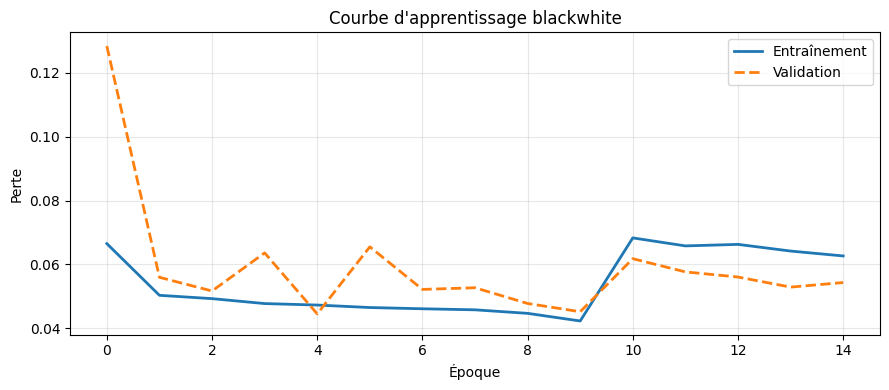

In [86]:
model_bw, history_bw = train_task(
    typeimage  = 'blackwhite',
    model_name = 'unet_bw_combined.keras',
    epochs     = 50,
    warmup     = 10,
    final_alpha      = 0.84
)

[make_generator] 18834 images au total (blackwhite, augment=False)


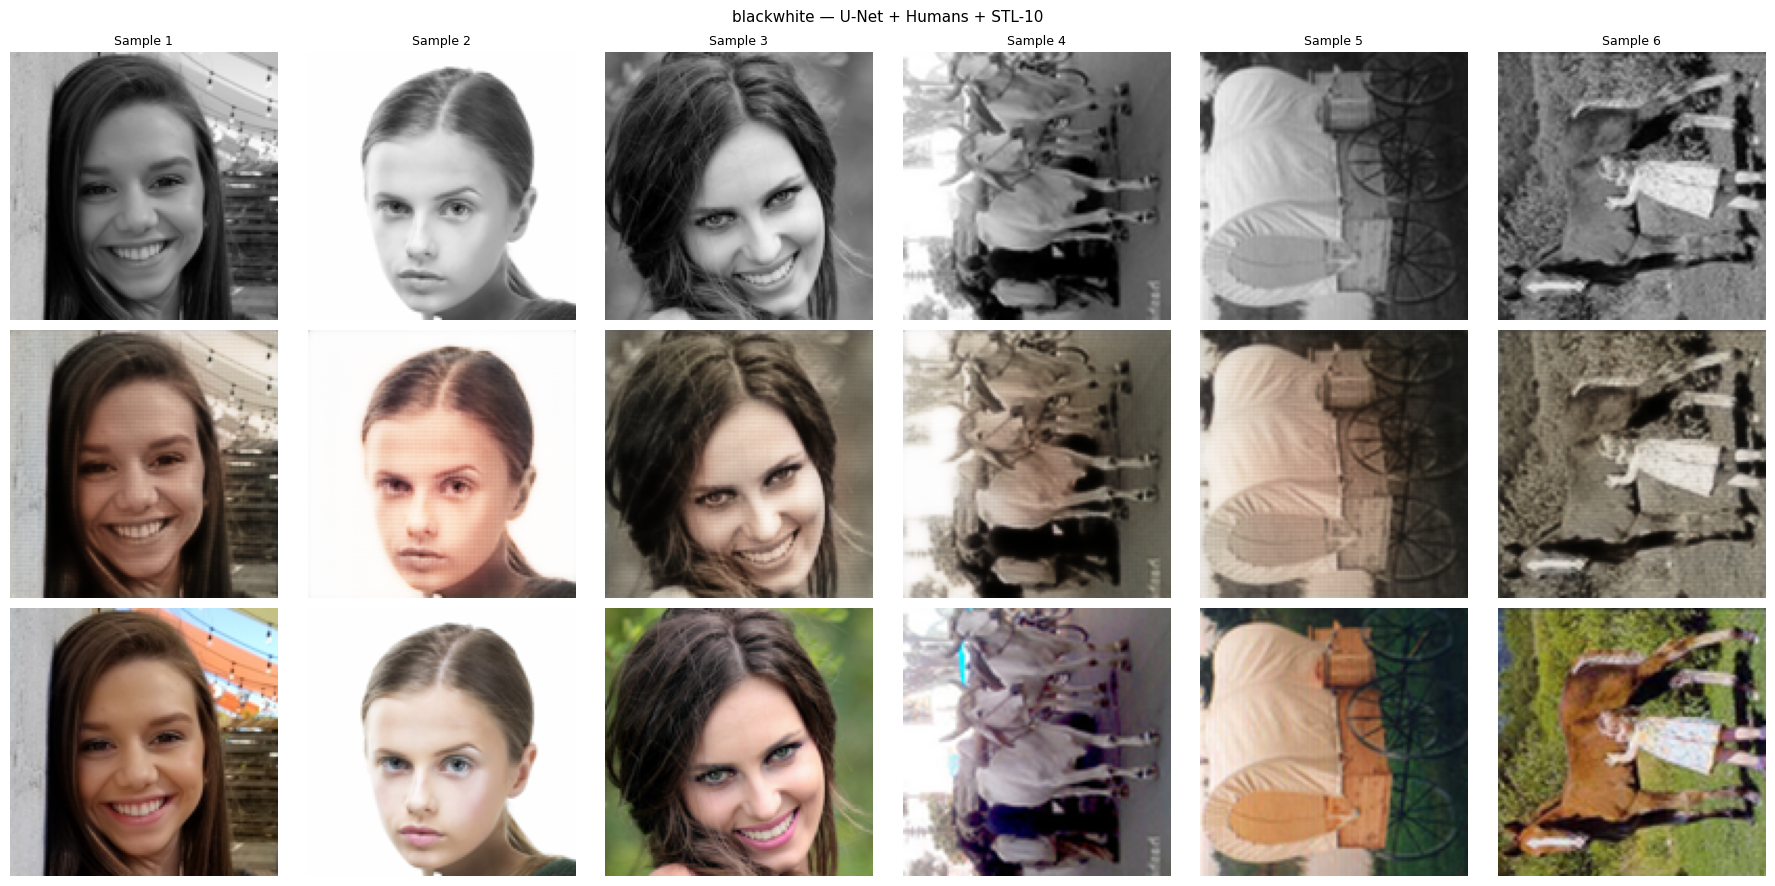

In [90]:
def compute_psnr(y_true, y_pred):
    return tf.reduce_mean(tf.image.psnr(y_true, y_pred, max_val=1.0))

def show_reconstruction(model, typeimage, n=6):
    gen             = make_generator(COMBINED_DIRS, TARGET_SIZE,
                                     batch_size=n, typeimage=typeimage,
                                     use_augment=False)
    corrupted, orig = next(gen)
    recon           = model.predict(corrupted, verbose=0)

    fig, axes = plt.subplots(3, n, figsize=(3 * n, 9))
    for i in range(n):
        score = compute_psnr(orig[i], recon[i]).numpy()
        color = 'green' if score > 25 else 'firebrick'
        cmap  = 'gray' if typeimage == 'blackwhite' else None

        axes[0, i].imshow(np.clip(corrupted[i], 0, 1), cmap=cmap)
        axes[0, i].axis('off')
        axes[0, i].set_title(f'Sample {i+1}', fontsize=9)

        axes[1, i].imshow(np.clip(recon[i], 0, 1))
        axes[1, i].axis('off')
        axes[1, i].set_xlabel(f'PSNR {score:.1f} dB', color=color, fontsize=8)

        axes[2, i].imshow(np.clip(orig[i], 0, 1))
        axes[2, i].axis('off')

    axes[0, 0].set_ylabel('N&B',          fontsize=11)
    axes[1, 0].set_ylabel('Reconstruite', fontsize=11)
    axes[2, 0].set_ylabel('Originale',    fontsize=11)
    plt.suptitle(f'{typeimage} — U-Net + Humans + STL-10', fontsize=11)
    plt.tight_layout()
    plt.show()

show_reconstruction(model_bw, 'blackwhite')

On remarque des teintes relativement correctes pour certains échantillons, mais le modèle échoue à reproduire fidèlement les couleurs vives, et tend parfois à halluciner des teintes différentes de celles attendues.

La désaturation observée est un comportement attendu, car la perte L1 tend à lisser les valeurs et à effectuer une sorte de moyenne des couleurs, ce qui conduit naturellement à des résultats plus ternes.

Le problème principal vient cependant de la courbe d’apprentissage : le modèle a été sauvegardé avant que la MS-SSIM ne soit pleinement activée. Il n’a donc pas correctement intégré la transition de α de 0.0 à 0.84, ce qui signifie qu’il n’a pas adapté son apprentissage à l’introduction progressive de cette composante perceptuelle. Ce point devra être corrigé dans les prochaines expériences.

In [24]:
class WarmupLossCallback(tf.keras.callbacks.Callback):
    """
    Montée progressive de alpha sur plusieurs époques après le warmup
    """
    def __init__(self, alpha_var, warmup_epochs, ramp_epochs=5, final_alpha=0.84):
        super().__init__()
        self.alpha_var    = alpha_var
        self.warmup_epochs = warmup_epochs
        self.ramp_epochs  = ramp_epochs
        self.final_alpha  = final_alpha

    def on_epoch_end(self, epoch, logs=None):
        e = epoch + 1
        if e < self.warmup_epochs:
            pass  # L1 pur
        elif e < self.warmup_epochs + self.ramp_epochs:
            progress = (e - self.warmup_epochs) / self.ramp_epochs
            new_alpha = self.final_alpha * progress
            self.alpha_var.assign(new_alpha)
            print(f'\n[WarmupLoss] époque {e} : alpha → {new_alpha:.3f}')
        else:
            self.alpha_var.assign(self.final_alpha)

cette version introduit une gestion plus contrôlée et progressive de la fonction de perte.

pour train_task le changement principal réside dans l’ajout d’un **ramp-up progressif de MS-SSIM** via un paramètre supplémentaire 
(`ramp_epochs`). dans l’ancienne version la transition entre L1 et MS-SSIM était trop brutale, on essaie de fixé cela.

De plus, le callback `WarmupLossCallback` est désormais plus précis dans sa gestion temporelle, avec une séparation claire entre :
- la phase de warm-up (L1 seul),
- la phase de transition progressive,
- la phase finale où MS-SSIM atteint son poids cible (`final_alpha`).

Une autre amélioration importante concerne le contrôle de l’entraînement :
- `EarlyStopping` est désormais configuré pour démarrer après la phase de transition, ce qui évite d’arrêter prématurément le modèle avant
que la perte perceptuelle ait pleinement pris effet.

Enfin, cette version vise à corriger un problème observé précédemment : le modèle sauvegardait des poids avant que MS-SSIM ne soit 
correctement intégré, ce qui empêchait l’adaptation complète de l’optimisation à la nouvelle fonction de perte.

In [24]:
def train_task(typeimage, model_name, epochs=EPOCHS, warmup=7, final_alpha=0.84):
    """
    Entraîne un U-Net propre sur une tâche de restauration

    Paramètres :
    - typeimage  : 'blackwhite', 'mask', 'noise', 'blur', 'combined'
    - model_name : nom du fichier .keras à sauvegarder
    - epochs     : nombre max d'époques
    - warmup     : nb d'époques avec L1 seul avant d'activer MS-SSIM
    - alpha      : poids de MS-SSIM dans mix_loss
    """
    print(f'\n{"═"*60}')
    print(f'  Tâche : {typeimage} saved in {model_name}, warmup : {warmup} ep.   alpha_final : {final_alpha}')
    print(f'{"═"*60}\n')

    model = get_fresh_model()
    # créer la loss et récupérer la var qu'on passera au callback
    loss_fn, alpha_var = make_warmup_loss(final_alpha=final_alpha)
    model.compile(optimizer=Adam(1e-3), loss=loss_fn)

    #n_images    = len([f for f in os.listdir(image_dir) if f.endswith('.png')])
    steps_train = max(1, int(n_total * 0.8) // BATCH_SIZE)
    steps_val   = max(1, int(n_total * 0.2) // BATCH_SIZE)

    train_gen = make_tf_dataset(COMBINED_DIRS, TARGET_SIZE, BATCH_SIZE, typeimage, use_augment=True)
    val_gen   = make_tf_dataset(COMBINED_DIRS, TARGET_SIZE, BATCH_SIZE, typeimage, use_augment=False)

    model_path = join(model_dir, model_name)

    callbacks = [
        WarmupLossCallback(alpha_var=alpha_var, warmup_epochs=warmup,ramp_epochs=5, final_alpha=final_alpha),
        EarlyStopping(
            monitor='val_loss', patience=PATIENCE,
            restore_best_weights=True, start_from_epoch=warmup + 5, verbose=1),
        ModelCheckpoint(
            filepath=model_path, monitor='val_loss',
            save_best_only=True, verbose=0 ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=4, min_lr=1e-6, verbose=1),
    ]

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )

    plot_history(history, typeimage)
    return model, history


def plot_history(history, title=''):
    """Courbe d'apprentissage avec annotation du point de switch loss."""
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(history.history['loss'],     label='Entraînement', lw=2)
    ax.plot(history.history['val_loss'], label='Validation',   lw=2, linestyle='--')
    ax.set_xlabel('Époque')
    ax.set_ylabel('Perte')
    ax.set_title(f"Courbe d'apprentissage {title}")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


════════════════════════════════════════════════════════════
  Tâche : blackwhite saved in unet_bw_combined_2.keras, warmup : 10 ep.   alpha_final : 0.84
════════════════════════════════════════════════════════════

[make_tf_dataset] 18834 images (blackwhite, augment=True)
[make_tf_dataset] 18834 images (blackwhite, augment=False)
Epoch 1/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 241s 325ms/step - loss: 0.0673 - val_loss: 0.1504 - learning_rate: 0.0010
Epoch 2/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 36s 121ms/step - loss: 0.0505 - val_loss: 0.0534 - learning_rate: 0.0010
Epoch 3/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 35s 118ms/step - loss: 0.0475 - val_loss: 0.0469 - learning_rate: 0.0010
Epoch 4/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 35s 119ms/step - loss: 0.0471 - val_loss: 0.0450 - learning_rate: 0.0010
Epoch 5/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 40s 116ms/step - loss: 0.0461 - val_loss: 0.0786 - learning_rate: 0.0010
Epoch 6/50
294/294 ━━━━━━━━━━━━━━━━━━━━ 35s 120ms/step - loss: 0.0465 - val_loss: 0.0561 - learning_

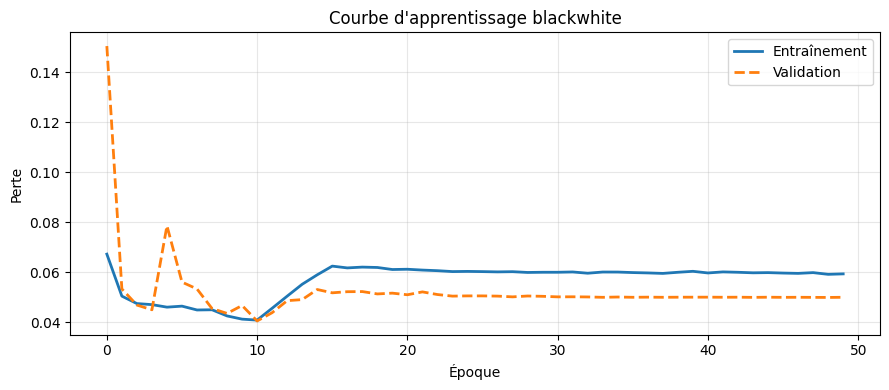

In [25]:
model_bw, history_bw = train_task(
    typeimage  = 'blackwhite',
    model_name = 'unet_bw_combined_2.keras',
    epochs     = 50,
    warmup     = 10,
    final_alpha      = 0.84
)

[make_tf_dataset] 18834 images (blackwhite, augment=False)


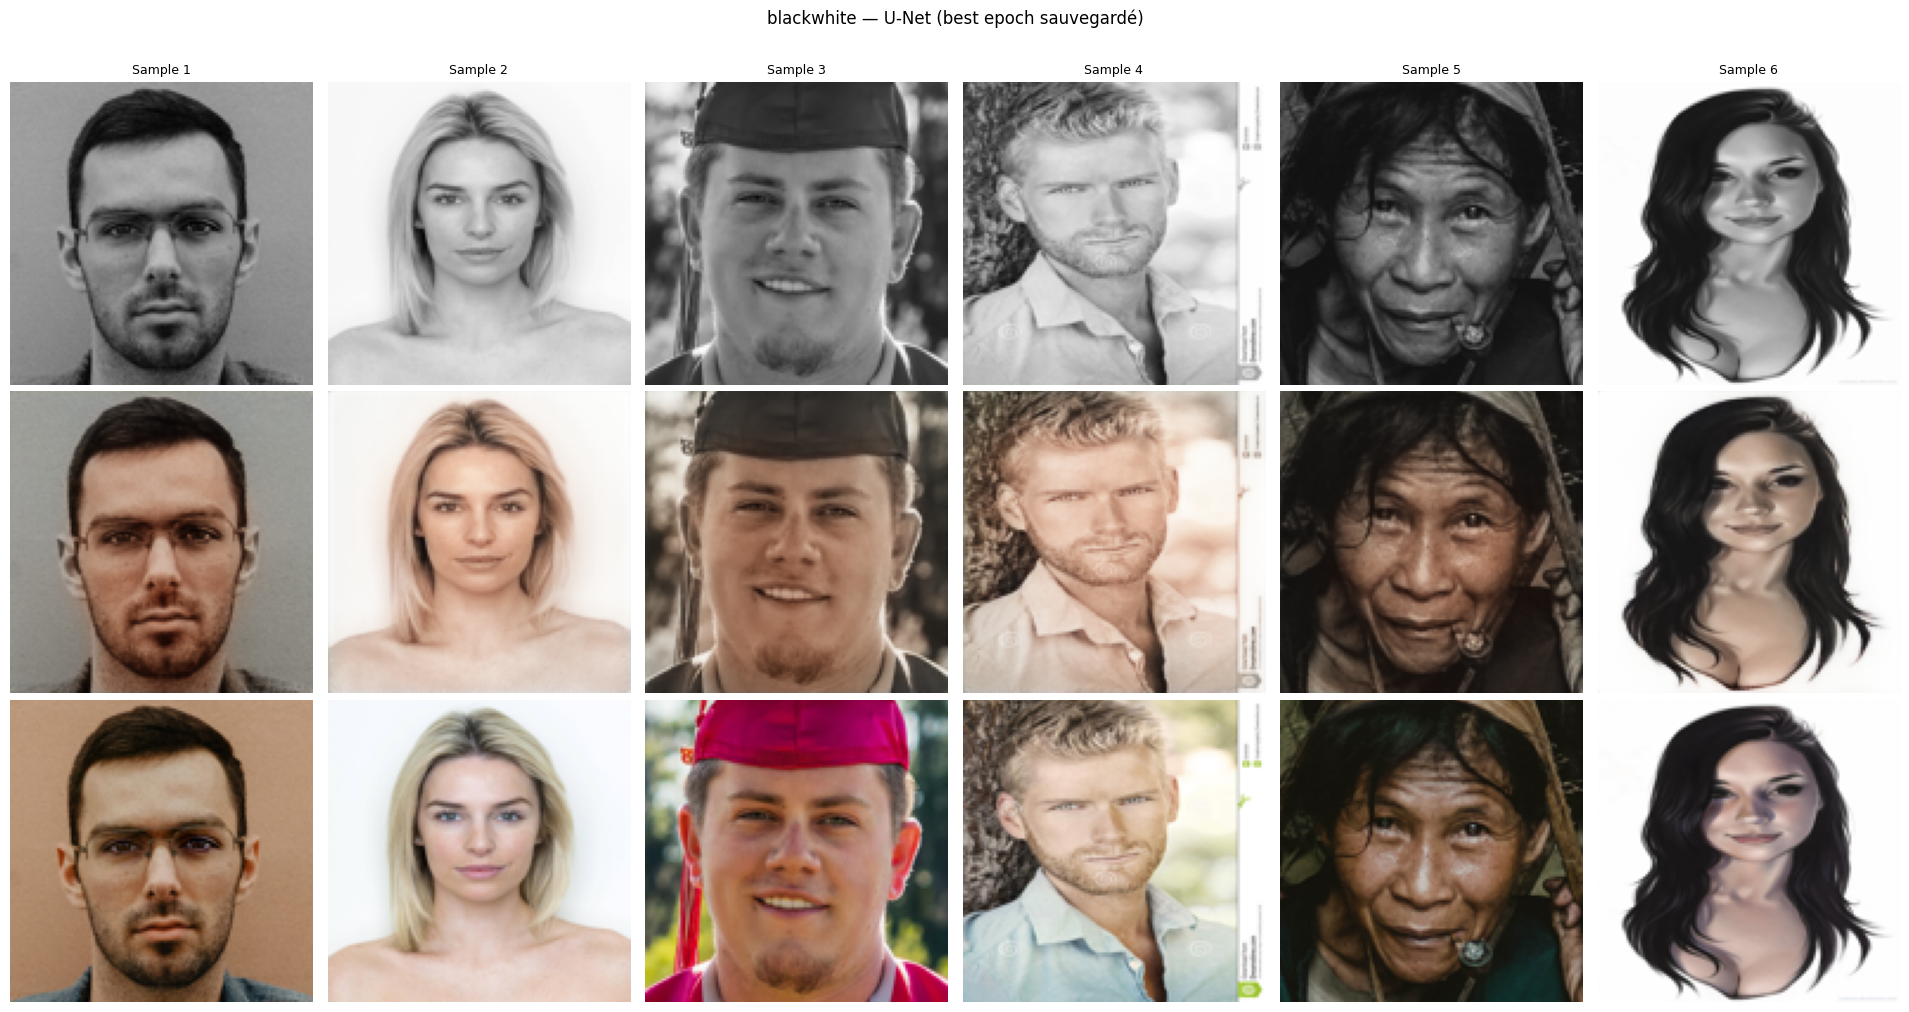


────────────────────────────────────────
  PSNR moyen : 26.95 dB  (±5.24)
  SSIM moyen : 0.9503  (±0.0533)
────────────────────────────────────────



In [28]:
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim

def show_reconstruction(model, typeimage, n=6, dataset_dirs=COMBINED_DIRS):
    """
    Affiche n triplets : (corrompue | reconstruite | originale)
    avec scores PSNR et SSIM par image.
    """
    ds = make_tf_dataset(dataset_dirs, TARGET_SIZE, batch_size=n,
                         typeimage=typeimage, use_augment=False)
    corr_batch, orig_batch = next(iter(ds))
    corr  = corr_batch.numpy()
    orig  = orig_batch.numpy()
    recon = model.predict(corr_batch, verbose=0)
    fig, axes = plt.subplots(3, n, figsize=(3.2 * n, 10))

    row_labels = {
        0: 'N&B (entrée)'  if typeimage == 'blackwhite' else f'{typeimage} (entrée)',
        1: 'Reconstruction',
        2: 'Originale',
    }
    cmap_input = 'gray' if typeimage == 'blackwhite' else None

    for i in range(n):
        orig_u8  = (np.clip(orig[i],  0, 1) * 255).astype(np.uint8)
        recon_u8 = (np.clip(recon[i], 0, 1) * 255).astype(np.uint8)

        psnr = compute_psnr(orig_u8, recon_u8, data_range=255)
        ssim = compute_ssim(orig_u8, recon_u8,
                            data_range=255, channel_axis=-1)

        psnr_color = 'green' if psnr > 25 else ('orange' if psnr > 20 else 'firebrick')

        # Ligne 0 : image corrompue
        axes[0, i].imshow(np.clip(corr[i], 0, 1), cmap=cmap_input)
        axes[0, i].set_title(f'Sample {i+1}', fontsize=9)
        axes[0, i].axis('off')

        # Ligne 1 : reconstruction
        axes[1, i].imshow(np.clip(recon[i], 0, 1))
        axes[1, i].set_xlabel(
            f'PSNR {psnr:.1f} dB  |  SSIM {ssim:.3f}',
            color=psnr_color, fontsize=8
        )
        axes[1, i].axis('off')

        # Ligne 2 : originale
        axes[2, i].imshow(np.clip(orig[i], 0, 1))
        axes[2, i].axis('off')

    # Labels des lignes
    for row, label in row_labels.items():
        axes[row, 0].set_ylabel(label, fontsize=11, labelpad=8)

    plt.suptitle(f'{typeimage} — U-Net (best epoch sauvegardé)', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

    psnr_scores, ssim_scores = [], []
    for i in range(n):
        o = (np.clip(orig[i],  0, 1) * 255).astype(np.uint8)
        r = (np.clip(recon[i], 0, 1) * 255).astype(np.uint8)
        psnr_scores.append(compute_psnr(o, r, data_range=255))
        ssim_scores.append(compute_ssim(o, r, data_range=255, channel_axis=-1))

    print(f"\n{'─'*40}")
    print(f"  PSNR moyen : {np.mean(psnr_scores):.2f} dB  (±{np.std(psnr_scores):.2f})")
    print(f"  SSIM moyen : {np.mean(ssim_scores):.4f}  (±{np.std(ssim_scores):.4f})")
    print(f"{'─'*40}\n")

show_reconstruction(model_bw, 'blackwhite', n=6)

**Remarques :**
on remarque que les résultat sont un peu mieux on a également psnr 2695 > 25 accptable, et ssim 0.95 qui généralement bon structurellement
mais les teintes sont toujours désaturées (orange/brein) qui est un biais de dataset , le modèle se concentre sur les visage mais background est généraliser.
pour le graphe de loss :

Epoch 1-10 (L1 pur)   : 0.0673 ->0.0413   descente propre
Epoch 11   (alpha=0.168)  : 0.0409        pas de spike
Epoch 12   (alpha=0.336)  : 0.0457        la loss mssim remet à l'échele
Epoch 13-50(alpha to->.84)  : plateau ~0.060 lr descend jusqu'à 1e-6, modèlebloqué
Best epoch  : 49, val_loss 0.0500

le meilleur checkpoint L1 était epoch 11 (val_loss=0.0406), mais après ça, MS-SSIM pousse la loss dans une autre direction que L1. Les deux métriques ne partagent pas la même échelle, MS-SSIM renvoie des valeurs ~10× plus grandes que L1 pour les mêmes images, donc à alpha=0.84 il domine trop et la val_loss L1-comparable semble monter alors que la qualité perceptuelle s'améliore peut-être.


# Amélioration des fonctions loss

In [29]:
def pure_l1(y_true, y_pred):
    return tf.reduce_mean(tf.abs(y_true - y_pred))

def lab_color_loss(y_true, y_pred):
    """
    Pénalise davantage les erreurs sur les canaux couleur (A, B)
    que sur la luminance (L).
    """
    # Conversion RGB LAB via une approximation TF
    def rgb_to_lab(img):
        img = tf.where(img > 0.04045,
                       tf.pow((img + 0.055) / 1.055, 2.4),
                       img / 12.92)

        r, g, b = img[...,0:1], img[...,1:2], img[...,2:3]
        x = 0.4124*r + 0.3576*g + 0.1805*b
        y = 0.2126*r + 0.7152*g + 0.0722*b
        z = 0.0193*r + 0.1192*g + 0.9505*b
        xyz = tf.concat([x/0.95047, y/1.00000, z/1.08883], axis=-1)

        eps = 0.008856
        xyz = tf.where(xyz > eps,
                       tf.pow(xyz, 1/3),
                       7.787*xyz + 16/116)
        L = 116*xyz[...,1:2] - 16
        A = 500*(xyz[...,0:1] - xyz[...,1:2])
        B = 200*(xyz[...,1:2] - xyz[...,2:3])
        return tf.concat([L/100, A/128, B/128], axis=-1)

    true_lab = rgb_to_lab(y_true)
    pred_lab = rgb_to_lab(y_pred)

    l_loss  = tf.reduce_mean(tf.abs(true_lab[...,0] - pred_lab[...,0]))
    ab_loss = tf.reduce_mean(tf.abs(true_lab[...,1:] - pred_lab[...,1:]))

    return l_loss + 3.0 * ab_loss

def ssim_simple(y_true, y_pred, max_val=1.0):
    C1 = (0.01 * max_val) ** 2
    C2 = (0.03 * max_val) ** 2

    def _fspecial_gauss(size, sigma):
        coords = tf.cast(tf.range(size), tf.float32) - (size - 1) / 2.0
        g = tf.exp(-(coords ** 2) / (2 * sigma ** 2))
        g = g / tf.reduce_sum(g)
        kernel = g[:, None] * g[None, :]
        kernel = kernel[:, :, None, None]
        return kernel

    kernel = _fspecial_gauss(11, 1.5)
    kernel = tf.tile(kernel, [1, 1, 3, 1])

    def apply_filter(x):
        return tf.nn.depthwise_conv2d(
            x, kernel, strides=[1,1,1,1], padding='SAME'
        )

    mu1 = apply_filter(y_true)
    mu2 = apply_filter(y_pred)

    mu1_sq = mu1 * mu1
    mu2_sq = mu2 * mu2
    mu1_mu2 = mu1 * mu2

    sigma1_sq = apply_filter(y_true * y_true) - mu1_sq
    sigma2_sq = apply_filter(y_pred * y_pred) - mu2_sq
    sigma12   = apply_filter(y_true * y_pred) - mu1_mu2

    numerator   = (2.0 * mu1_mu2 + C1) * (2.0 * sigma12 + C2)
    denominator = (mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2)

    ssim_map = numerator / (denominator + 1e-8)
    return tf.reduce_mean(ssim_map)


def make_warmup_loss(final_alpha=0.5):
    alpha_var = tf.Variable(0.0, trainable=False, dtype=tf.float32)

    def loss_fn(y_true, y_pred):
        l1  = tf.reduce_mean(tf.abs(y_true - y_pred))
        lab = lab_color_loss(y_true, y_pred)
        ms  = 1.0 - ssim_simple(y_true, y_pred)

        return (1.0 - alpha_var) * (0.5 * l1 + 0.5 * lab) + alpha_var * ms

    loss_fn.__name__ = 'warmup_mix_loss'
    return loss_fn, alpha_var

In [30]:
def train_task(typeimage, model_name, epochs=EPOCHS, warmup=7, ramp_epochs=5, final_alpha=0.5):
    """
    Entraîne un U-Net propre sur une tâche de restauration

    Paramètres :
    - typeimage  : 'blackwhite', 'mask', 'noise', 'blur', 'combined'
    - model_name : nom du fichier .keras à sauvegarder
    - epochs     : nombre max d'époques
    - warmup     : nb d'époques avec L1 seul avant d'activer MS-SSIM
    - ramp_epochs : nombre d'époques pour monter alpha progressivement après le warmup
    - alpha      : poids de MS-SSIM dans mix_loss
    """
    import gc
    tf.keras.backend.clear_session()
    gc.collect()

    print(f'\n{"═"*60}')
    print(f'  Tâche : {typeimage} saved in {model_name}, warmup : {warmup} ep.   alpha_final : {final_alpha}')
    print(f'{"═"*60}\n')

    model = get_fresh_model()
    # créer la loss et récupérer la var qu'on passera au callback
    loss_fn, alpha_var = make_warmup_loss(final_alpha=final_alpha)
    model.compile(optimizer=Adam(1e-3), loss=loss_fn, metrics=[pure_l1])

    #n_images    = len([f for f in os.listdir(image_dir) if f.endswith('.png')])
    steps_train = max(1, int(n_total * 0.8) // BATCH_SIZE)
    steps_val   = max(1, int(n_total * 0.2) // BATCH_SIZE)

    train_gen = make_tf_dataset(COMBINED_DIRS, TARGET_SIZE, BATCH_SIZE, typeimage, use_augment=True)
    val_gen   = make_tf_dataset(COMBINED_DIRS, TARGET_SIZE, BATCH_SIZE, typeimage, use_augment=False)

    callbacks = [
        WarmupLossCallback(alpha_var=alpha_var, warmup_epochs=warmup,ramp_epochs=ramp_epochs, final_alpha=final_alpha),
        EarlyStopping(
            monitor='val_pure_l1', patience=PATIENCE, start_from_epoch= warmup + ramp_epochs,mode='min',
            restore_best_weights=True, verbose=1),

        ModelCheckpoint(
            filepath=join(model_dir, 'checkpoint_epoch{epoch:02d}.keras'),
            save_freq='epoch', monitor='val_pure_l1',mode='min',
            save_best_only=True, verbose=0 ),

        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=7, min_lr=1e-6, verbose=1),
    ]

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs,
        steps_per_epoch=steps_train,
        validation_steps=steps_val,
        callbacks=callbacks,
        verbose=1
    )

    plot_history(history, typeimage)
    return model, history


def plot_history(history, title=''):
    """Courbe d'apprentissage avec annotation du point de switch loss."""
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(history.history['loss'],     label='Entraînement', lw=2)
    ax.plot(history.history['val_loss'], label='Validation',   lw=2, linestyle='--')
    ax.set_xlabel('Époque')
    ax.set_ylabel('Perte')
    ax.set_title(f"Courbe d'apprentissage {title}")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


════════════════════════════════════════════════════════════
  Tâche : blackwhite saved in unet_bw_combined_3.keras, warmup : 10 ep.   alpha_final : 0.84
════════════════════════════════════════════════════════════

[make_tf_dataset] 18834 images (blackwhite, augment=True)
[make_tf_dataset] 18834 images (blackwhite, augment=False)
Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 174s 318ms/step - loss: 0.1571 - pure_l1: 0.0777 - val_loss: 0.2733 - val_pure_l1: 0.1803 - learning_rate: 0.0010
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 74s 317ms/step - loss: 0.1223 - pure_l1: 0.0512 - val_loss: 0.2137 - val_pure_l1: 0.1032 - learning_rate: 0.0010
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 73s 311ms/step - loss: 0.1188 - pure_l1: 0.0488 - val_loss: 0.1217 - val_pure_l1: 0.0512 - learning_rate: 0.0010
Epoch 4/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 71s 303ms/step - loss: 0.1195 - pure_l1: 0.0483 - val_loss: 0.1184 - val_pure_l1: 0.0482 - learning_rate: 0.0010
Epoch 5/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 70s 297ms/ste

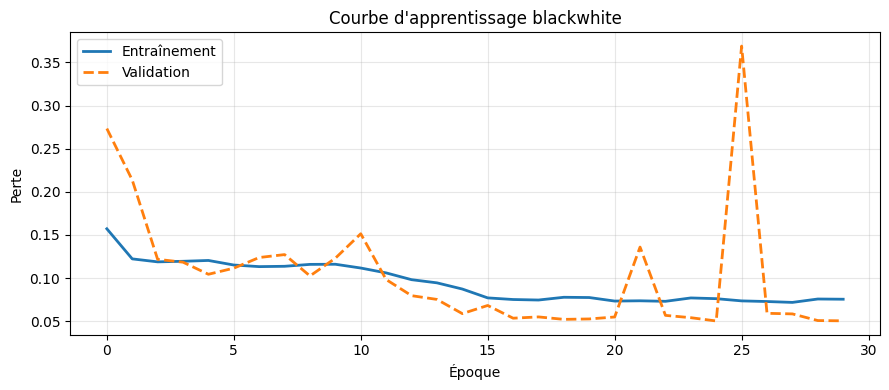

In [31]:
# model_bw, history_bw = train_task(
#     typeimage  = 'blackwhite',
#     model_name = 'unet_bw_combined_3.keras',
#     epochs     = 30, #because of ram space on google collab
#     warmup     = 10,
#     final_alpha      = 0.84
# )

In [29]:
print(os.listdir('./aeplus_models/'))

['unet_bw_combined.keras', 'unet_bw_combined_2.keras', 'unet_bw_combined_3.keras', 'checkpoint_epoch01.keras', 'checkpoint_epoch02.keras', 'checkpoint_epoch03.keras', 'checkpoint_epoch04.keras', 'checkpoint_epoch05.keras', 'checkpoint_epoch09.keras', 'checkpoint_epoch12.keras', 'checkpoint_epoch13.keras', 'checkpoint_epoch15.keras', 'checkpoint_epoch25.keras']


[make_tf_dataset] 18834 images (blackwhite, augment=False)


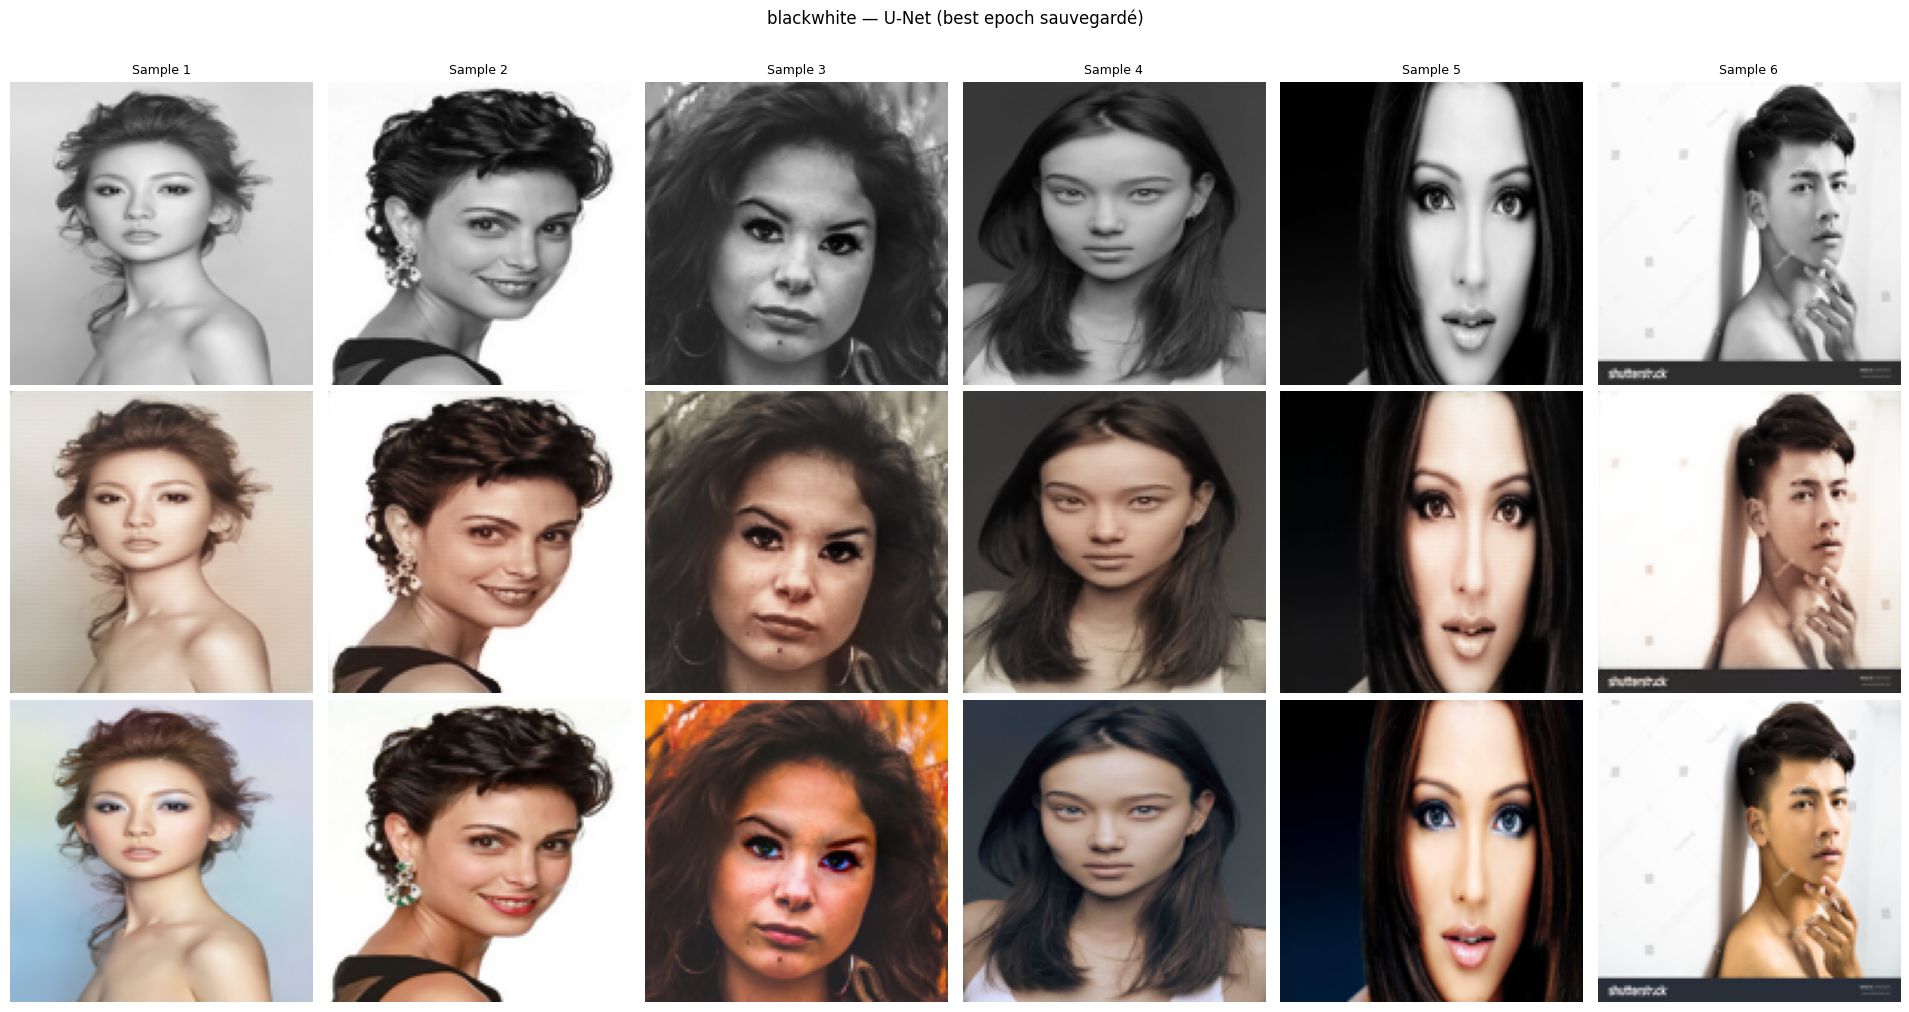


────────────────────────────────────────
  PSNR moyen : 27.12 dB  (±3.90)
  SSIM moyen : 0.9497  (±0.0333)
────────────────────────────────────────



In [30]:
from skimage.metrics import peak_signal_noise_ratio as compute_psnr
from skimage.metrics import structural_similarity as compute_ssim

def show_reconstruction(model, typeimage, n=6, dataset_dirs=COMBINED_DIRS):
    """
    Affiche n triplets : (corrompue | reconstruite | originale)
    avec scores PSNR et SSIM par image.
    """
    ds = make_tf_dataset(dataset_dirs, TARGET_SIZE, batch_size=n,
                         typeimage=typeimage, use_augment=False)
    corr_batch, orig_batch = next(iter(ds))
    corr  = corr_batch.numpy()
    orig  = orig_batch.numpy()
    recon = model.predict(corr_batch, verbose=0)
    fig, axes = plt.subplots(3, n, figsize=(3.2 * n, 10))

    row_labels = {
        0: 'N&B (entrée)'  if typeimage == 'blackwhite' else f'{typeimage} (entrée)',
        1: 'Reconstruction',
        2: 'Originale',
    }
    cmap_input = 'gray' if typeimage == 'blackwhite' else None

    for i in range(n):
        orig_u8  = (np.clip(orig[i],  0, 1) * 255).astype(np.uint8)
        recon_u8 = (np.clip(recon[i], 0, 1) * 255).astype(np.uint8)

        psnr = compute_psnr(orig_u8, recon_u8, data_range=255)
        ssim = compute_ssim(orig_u8, recon_u8,
                            data_range=255, channel_axis=-1)

        psnr_color = 'green' if psnr > 25 else ('orange' if psnr > 20 else 'firebrick')

        # Ligne 0 : image corrompue
        axes[0, i].imshow(np.clip(corr[i], 0, 1), cmap=cmap_input)
        axes[0, i].set_title(f'Sample {i+1}', fontsize=9)
        axes[0, i].axis('off')

        # Ligne 1 : reconstruction
        axes[1, i].imshow(np.clip(recon[i], 0, 1))
        axes[1, i].set_xlabel(
            f'PSNR {psnr:.1f} dB  |  SSIM {ssim:.3f}',
            color=psnr_color, fontsize=8
        )
        axes[1, i].axis('off')

        # Ligne 2 : originale
        axes[2, i].imshow(np.clip(orig[i], 0, 1))
        axes[2, i].axis('off')

    # Labels des lignes
    for row, label in row_labels.items():
        axes[row, 0].set_ylabel(label, fontsize=11, labelpad=8)

    plt.suptitle(f'{typeimage} — U-Net (best epoch sauvegardé)', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()

    psnr_scores, ssim_scores = [], []
    for i in range(n):
        o = (np.clip(orig[i],  0, 1) * 255).astype(np.uint8)
        r = (np.clip(recon[i], 0, 1) * 255).astype(np.uint8)
        psnr_scores.append(compute_psnr(o, r, data_range=255))
        ssim_scores.append(compute_ssim(o, r, data_range=255, channel_axis=-1))

    print(f"\n{'─'*40}")
    print(f"  PSNR moyen : {np.mean(psnr_scores):.2f} dB  (±{np.std(psnr_scores):.2f})")
    print(f"  SSIM moyen : {np.mean(ssim_scores):.4f}  (±{np.std(ssim_scores):.4f})")
    print(f"{'─'*40}\n")

model_bw = tf.keras.models.load_model(
    './aeplus_models/checkpoint_epoch25.keras',
    compile=False
)

show_reconstruction(model_bw, 'blackwhite', n=6)